<div style="background-color:#d5f5e3; padding:20px; border-left:8px solid #27AE60; border-radius:8px; color:#1b1b1b;">

## **Proyecto árbol de decisión**

**Autora:** Anais Aponte  
**Bootcamp:** 4Geeks Academy – Intro to Machine Learning  
**Proyecto:** Proyecto árbol de decisión  

</div>

<div style="background-color:#d6eaff; border-left:6px solid #4a90e2; padding:15px; border-radius:8px; color:#1b1b1b;">

### 📝 **Instrucciones**

#### **Prediciendo la diabetes**

El objetivo es predecir en base a medidas diagnósticas si un paciente tiene o no diabetes

</div>

<div style="background-color:#d6eaff; border-left:6px solid #4a90e2; padding:15px; border-radius:8px; color:#1b1b1b;">

### 📝 **Paso 1: Carga del conjunto de datos**

El dataset utilizado en este proyecto es **diabetes.csv**.

Para facilitar la reproducibilidad y evitar dependencias externas, el archivo ha sido previamente descargado y almacenado dentro del repositorio en la siguiente ruta:

📁 `data/raw/diabetes.csv`

De esta forma, el notebook puede ejecutarse directamente sin necesidad de acceder a enlaces externos.

A continuación se realizan primero las importaciones necesarias y, posteriormente, la carga del dataset para iniciar el análisis.

</div>

In [1]:
# ==========================================
# 📦 IMPORTACIÓN DE LIBRERÍAS (GLOBAL)
# ==========================================

# Manipulación de datos
import pandas as pd
import numpy as np

# Visualización
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración visual (opcional pero útil)
sns.set(style="whitegrid")

# Preprocesamiento
from sklearn.impute import SimpleImputer

# División de datos
from sklearn.model_selection import train_test_split, GridSearchCV

# Modelos
from sklearn.tree import DecisionTreeClassifier, plot_tree

# Métricas
from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
)

# Importamos la librería para guardar modelos
import joblib


In [2]:
# CARGAMOS EL FICHERO CON LOS DATOS A ANALIZAR
df = pd.read_csv('../data/raw/diabetes.csv')

# Visualizamos 10 registros aleatorios del dataset con sample(). Esto nos permite observar una muestra representativa de los datos,
# ya que algunos datasets pueden estar ordenados (por fecha, id, etc.).
df.sample(10)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
341,1,95,74,21,73,25.9,0.673,36,0
487,0,173,78,32,265,46.5,1.159,58,0
7,10,115,0,0,0,35.3,0.134,29,0
125,1,88,30,42,99,55.0,0.496,26,1
325,1,157,72,21,168,25.6,0.123,24,0
377,1,87,60,37,75,37.2,0.509,22,0
405,2,123,48,32,165,42.1,0.520,26,0
703,2,129,0,0,0,38.5,0.304,41,0
711,5,126,78,27,22,29.6,0.439,40,0
690,8,107,80,0,0,24.6,0.856,34,0


<div style="background-color:#fff3cd; border-left:6px solid #f1c40f; padding:15px; border-radius:8px; color:#1b1b1b;">

A continuación se detallan las variables incluidas en el dataset:

### 📊 Diccionario de Datos

| Variable | Descripción | Tipo |
|----------|------------|------|
| Pregnancies | Número de embarazos del paciente | Numérico |
| Glucose | Concentración de glucosa en plasma a las 2 horas de un test de tolerancia oral a la glucosa | Numérico |
| BloodPressure | Presión arterial diastólica (mm Hg) | Numérico |
| SkinThickness | Grosor del pliegue cutáneo del tríceps (mm) | Numérico |
| Insulin | Insulina sérica a las 2 horas (mu U/ml) | Numérico |
| BMI | Índice de masa corporal | Numérico |
| DiabetesPedigreeFunction | Función de pedigrí de diabetes | Numérico |
| Age | Edad del paciente | Numérico |
| Outcome | Variable objetivo (0 = negativo en diabetes, 1 = positivo) | Numérico |

Este diccionario de datos será clave para interpretar correctamente las relaciones entre variables durante el análisis exploratorio (EDA).

</div>

<div style="background-color:#fff3cd; border-left:6px solid #f1c40f; padding:15px; border-radius:8px; color:#1b1b1b;">

### 💡 **Observación inicial**

El dataset parece contener información médica relacionada con la salud de pacientes, incluyendo variables como niveles de glucosa, presión arterial, índice de masa corporal y otros indicadores clínicos. 

</div>

<div style="background-color:#d6eaff; border-left:6px solid #4a90e2; padding:15px; border-radius:8px; color:#1b1b1b;">

### **Paso 2: Realiza un EDA completo**

</div>

<div style="background-color:#d6eaff; border-left:6px solid #4a90e2; padding:15px; border-radius:8px; color:#1b1b1b;">

### **Paso 2.1: Inspección inicial del dataset**

</div>

In [3]:
# Obtener las dimensiones
df.shape

(768, 9)

In [4]:
# Obtener información sobre tipos de datos y valores no nulos
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [5]:
# Valores nulos
df.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

<div style="background-color:#fff3cd; padding:20px; border-left:8px solid #ffcc00; border-radius:8px; color:#1b1b1b;">

### 💡 **Observación sobre la estructura del dataset**

El dataset cuenta con **768 observaciones y 9 variables**, lo que lo convierte en un conjunto de datos manejable.

Todas las variables son de tipo numérico, lo que simplifica el proceso de modelado, ya que no será necesario aplicar técnicas de codificación de variables categóricas.

Además, no se observan valores nulos en ninguna de las columnas, lo cual es una ventaja importante, ya que evita la necesidad de aplicar técnicas de imputación o eliminación de datos.

Esto permite avanzar directamente hacia el análisis exploratorio sin necesidad de realizar tareas complejas de limpieza de datos.

</div>

<div style="background-color:#d6eaff; border-left:6px solid #4a90e2; padding:15px; border-radius:8px; color:#1b1b1b;">

### **Paso 2.2: Inspección valores unicos y duplicados**

</div>

In [6]:
# Veamos cuantos valores unicos y no unicos (repetidos) hay en cada variable

df_uniques = df.nunique()
df_repeated = len(df) - df_uniques

resumen = pd.DataFrame({
    'valores_unicos': df_uniques,
    'valores_repetidos': df_repeated
})

resumen

,valores_unicos,valores_repetidos
Pregnancies,17,751
Glucose,136,632
BloodPressure,47,721
SkinThickness,51,717
Insulin,186,582
BMI,248,520
DiabetesPedigreeFunction,517,251
Age,52,716
Outcome,2,766


In [7]:
# Veamos si existe duplicado de filas (filas completamente identicas en todas su variables en el dataset)
df.duplicated().sum()

np.int64(0)

In [8]:
# Veamos si hay columnas duplicadas entre sí
df.T.duplicated()

Pregnancies                 False
Glucose                     False
BloodPressure               False
SkinThickness               False
Insulin                     False
BMI                         False
DiabetesPedigreeFunction    False
Age                         False
Outcome                     False
dtype: bool

<div style="background-color:#fff3cd; border-left:6px solid #f1c40f; padding:15px; border-radius:8px; color:#1b1b1b;">

### 💡 **Observación sobre valores únicos y duplicados**

No se han encontrado filas duplicadas en el dataset, lo cual es positivo ya que indica que no existen registros completamente repetidos que puedan sesgar el análisis.

Tampoco se detectan columnas duplicadas entre sí, por lo que todas las variables aportan información distinta.

En cuanto al análisis de valores únicos por variable, este no resulta especialmente relevante en este caso, ya que todas las variables son numéricas continuas y no existen variables categóricas o identificadores donde la cardinalidad sea un factor crítico.


</div>

<div style="background-color:#d6eaff; border-left:6px solid #4a90e2; padding:15px; border-radius:8px; color:#1b1b1b;">

### **Paso 2.3: Análisis estadístico descriptivo**

</div>

In [9]:
# Se calculan estadísticas descriptivo para las variables numericas comprender su distribución, rango de valores y posibles valores outliers
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


<div style="background-color:#fff3cd; border-left:6px solid #f1c40f; padding:15px; border-radius:8px; color:#1b1b1b;">


### 💡 **Observación sobre estadísticas descriptivas**

A partir del análisis descriptivo se identifican varios aspectos relevantes del dataset.

En primer lugar, se observan valores mínimos iguales a 0 en variables como `Glucose`, `BloodPressure`, `SkinThickness`, `Insulin` y `BMI`. Dado el contexto médico, estos valores no son realistas, por lo que podrían representar valores ausentes codificados como 0.

Por otro lado, variables como *Insulin* presentan una alta dispersión, con una diferencia considerable entre el valor medio y el máximo, lo que sugiere la posible presencia de valores extremos.

Finalmente, la variable objetivo (`Outcome`) muestra una proporción mayor de casos negativos que positivos, lo que indica un posible desbalance de clases que deberá tenerse en cuenta en fases posteriores del modelado.

</div>


<div style="background-color:#d6eaff; border-left:6px solid #4a90e2; padding:15px; border-radius:8px; color:#1b1b1b;">

### **Paso 2.4: Análisis de valores nulos**

</div>

In [10]:
# Contar ceros por columna en todo el dataset
ceros = (df == 0).sum()

# Convertir a DataFrame para verlo mejor
ceros_df = ceros.to_frame(name='num_ceros')

# Añadir porcentaje
ceros_df['porcentaje'] = (ceros_df['num_ceros'] / len(df)) * 100

# Ordenar de mayor a menor (muy útil 🔥)
ceros_df = ceros_df.sort_values(by='num_ceros', ascending=False)

ceros_df

,num_ceros,porcentaje
Outcome,500,65.104167
Insulin,374,48.697917
SkinThickness,227,29.557292
Pregnancies,111,14.453125
BloodPressure,35,4.557292
BMI,11,1.432292
Glucose,5,0.651042
DiabetesPedigreeFunction,0,0.000000
Age,0,0.000000


<div style="background-color:#fff3cd; border-left:6px solid #f1c40f; padding:15px; border-radius:8px; color:#1b1b1b;">


### 💡 **Observación: Valores cero como posibles datos faltantes**

Existen valores iguales a 0 en variables como `Glucose`, `BloodPressure`, `SkinThickness`, `Insulin` y `BMI`, los cuales no son realistas en un contexto médico.

Esto sugiere que dichos valores representan datos faltantes codificados como 0.

Destaca especialmente `Insulin`, con un alto porcentaje de ceros (~49%), lo que indica una baja calidad de esta variable.

Por otro lado, la variable `Pregnancies` presenta valores cero plausibles (ausencia de embarazos), por lo que no requiere tratamiento.

Dado que estos valores iguales a 0 no son plausibles y pueden distorsionar la distribución real de las variables, existe el riesgo de que el modelo aprenda relaciones incorrectas durante el entrenamiento. 

Por ello, en la fase de ingeniería de características se optará por imputar estos valores en lugar de eliminar registros, preservando la información disponible y prestando especial atención a variables relevantes como `Glucose` y `BMI`.

</div>


<div style="background-color:#d6eaff; border-left:6px solid #4a90e2; padding:15px; border-radius:8px; color:#1b1b1b;">

### **Paso 2.4: Análisis univariable (variables numericas)**

</div>

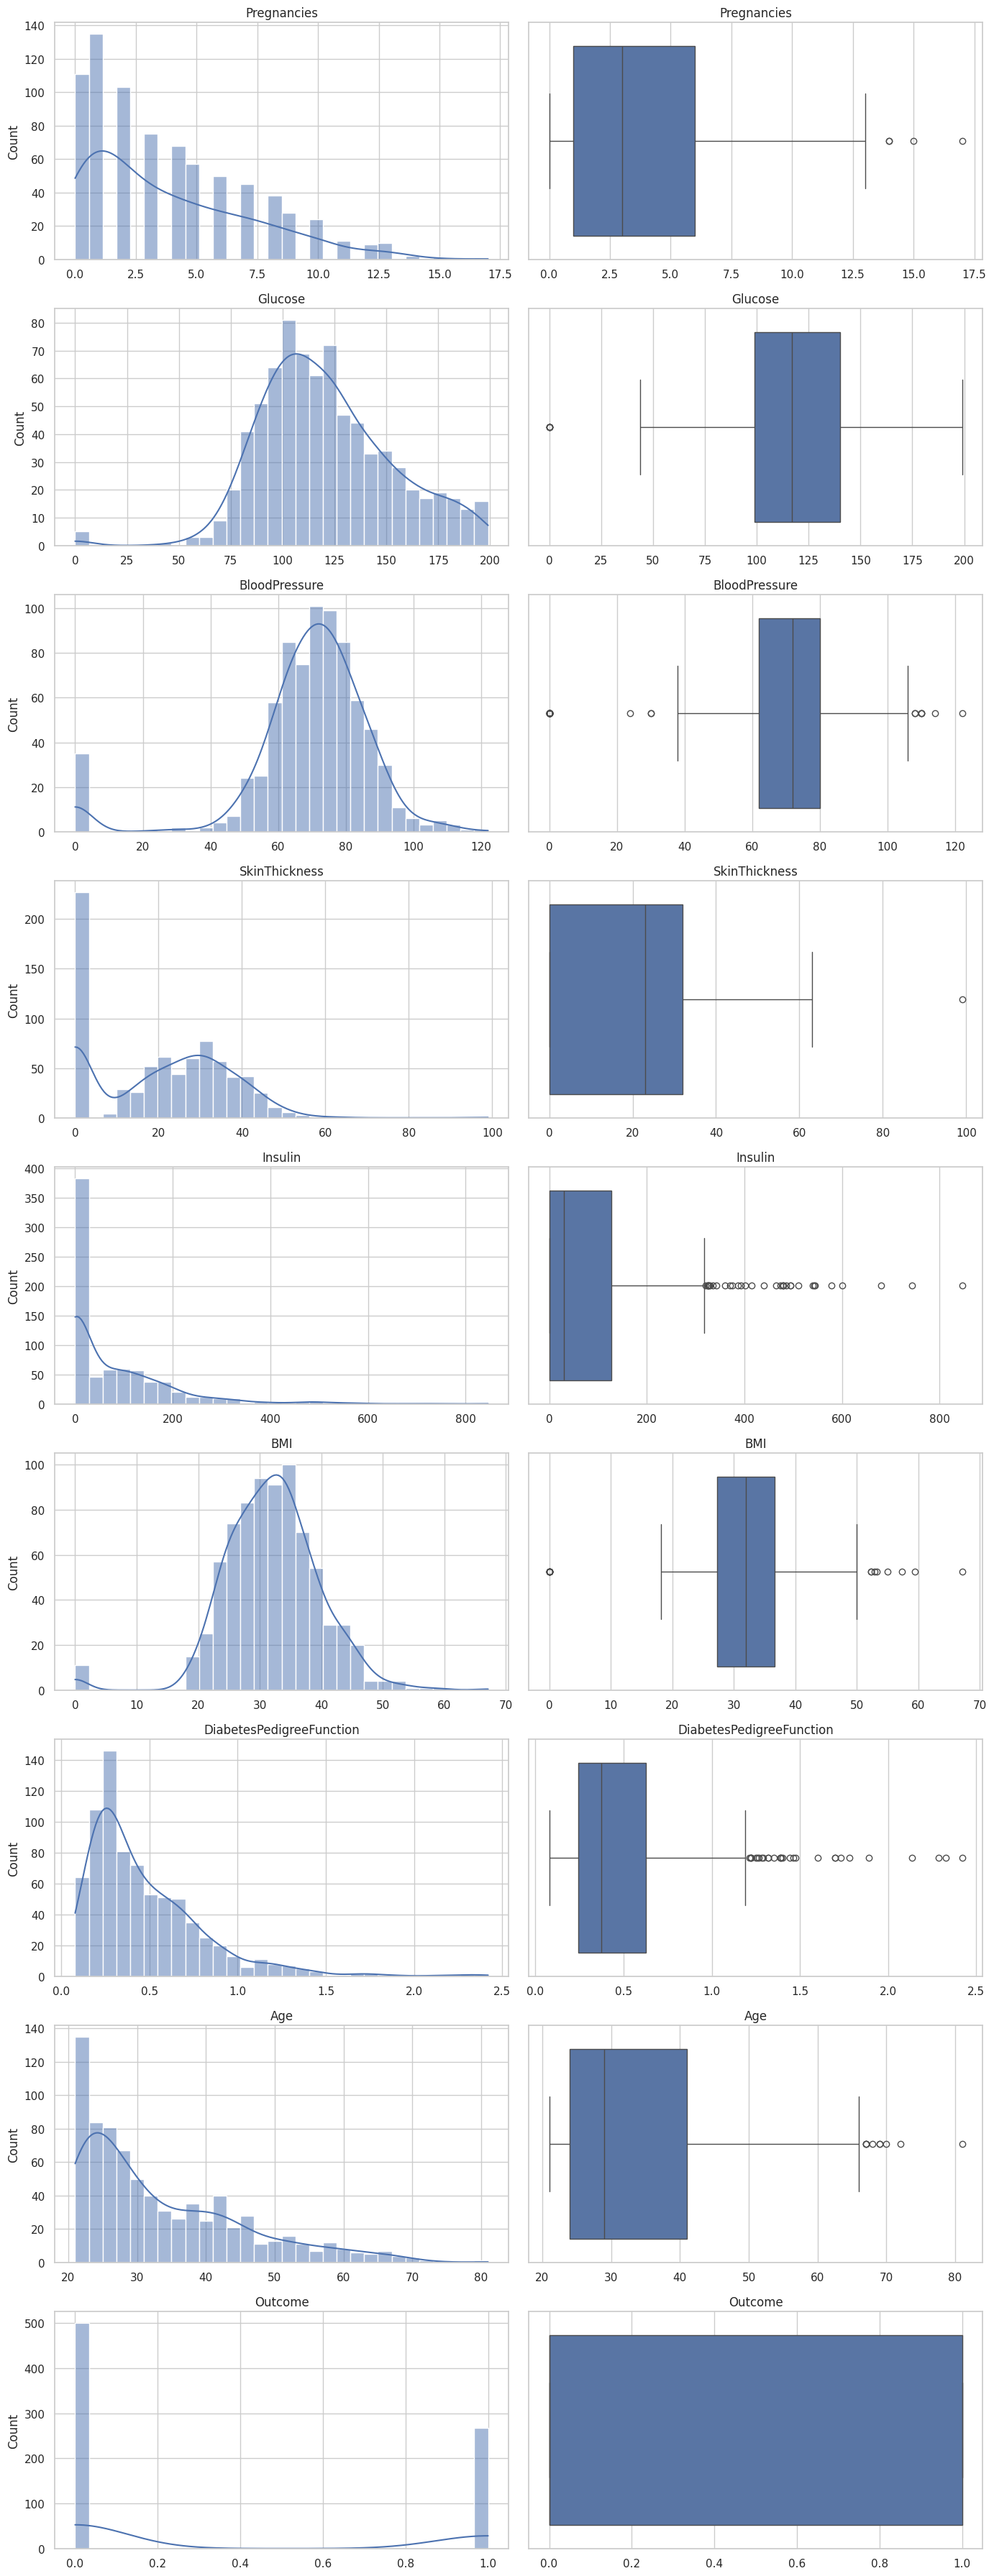

In [11]:
# Seleccionamos variables numéricas
num_vars = df.select_dtypes(include=['int64', 'float64']).columns

# Estilo limpio
sns.set_style("whitegrid")

# 🔥 Más grande y más aire entre gráficos
fig, axes = plt.subplots(len(num_vars), 2, figsize=(14, 4*len(num_vars)))

for i, col in enumerate(num_vars):

    # Histograma
    sns.histplot(df[col], bins=30, ax=axes[i, 0], kde=True)
    axes[i, 0].set_title(f'{col}')
    axes[i, 0].set_xlabel('')

    # Boxplot
    sns.boxplot(x=df[col], ax=axes[i, 1])
    axes[i, 1].set_title(f'{col}')
    axes[i, 1].set_xlabel('')

plt.tight_layout()
plt.show()

<div style="background-color:#fff3cd; border-left:6px solid #f1c40f; padding:15px; border-radius:8px; color:#1b1b1b;">

### 💡 **Observación sobre el análisis univariante**

A partir de la visualización de las variables numéricas mediante histogramas y boxplots, se identifican varios patrones relevantes en el dataset.

En primer lugar, se observa la presencia de valores iguales a 0 en variables como `Glucose`, `BloodPressure`, `SkinThickness`, `Insulin` y `BMI`, concentrándose en algunos casos como un pico en la distribución. Esto refuerza la hipótesis previa de que estos valores podrían representar datos faltantes codificados como 0.

Por otro lado, variables como `Insulin`, `BMI`, `DiabetesPedigreeFunction` y `Age` presentan distribuciones sesgadas hacia la derecha, con presencia de valores extremos, lo que se evidencia claramente en los boxplots.

Asimismo, algunas variables como `Glucose` y `BloodPressure` muestran distribuciones más cercanas a una forma normal, aunque siguen presentando ciertos valores atípicos.

Finalmente, la variable objetivo `Outcome` confirma el desbalance de clases observado previamente, con una mayor concentración de casos negativos (0) frente a positivos (1).

</div>

<div style="background-color:#d6eaff; border-left:6px solid #4a90e2; padding:15px; border-radius:8px; color:#1b1b1b;">

### **Paso 2.4: Análisis univariable (variables categóricas)**

</div>

<div style="background-color:#fff3cd; border-left:6px solid #f1c40f; padding:15px; border-radius:8px; color:#1b1b1b;">

### 💡 **Observación: Análisis univariante (variables categóricas)**

En este dataset no se identifican variables categóricas, ya que todas las variables son de tipo numérico.

Por tanto, este paso no aplica en el análisis exploratorio actual.

</div>


<div style="background-color:#d6eaff; border-left:6px solid #4a90e2; padding:15px; border-radius:8px; color:#1b1b1b;">

### **Paso 2.6: Analisis bivariante (numéricas vs target)**

</div>

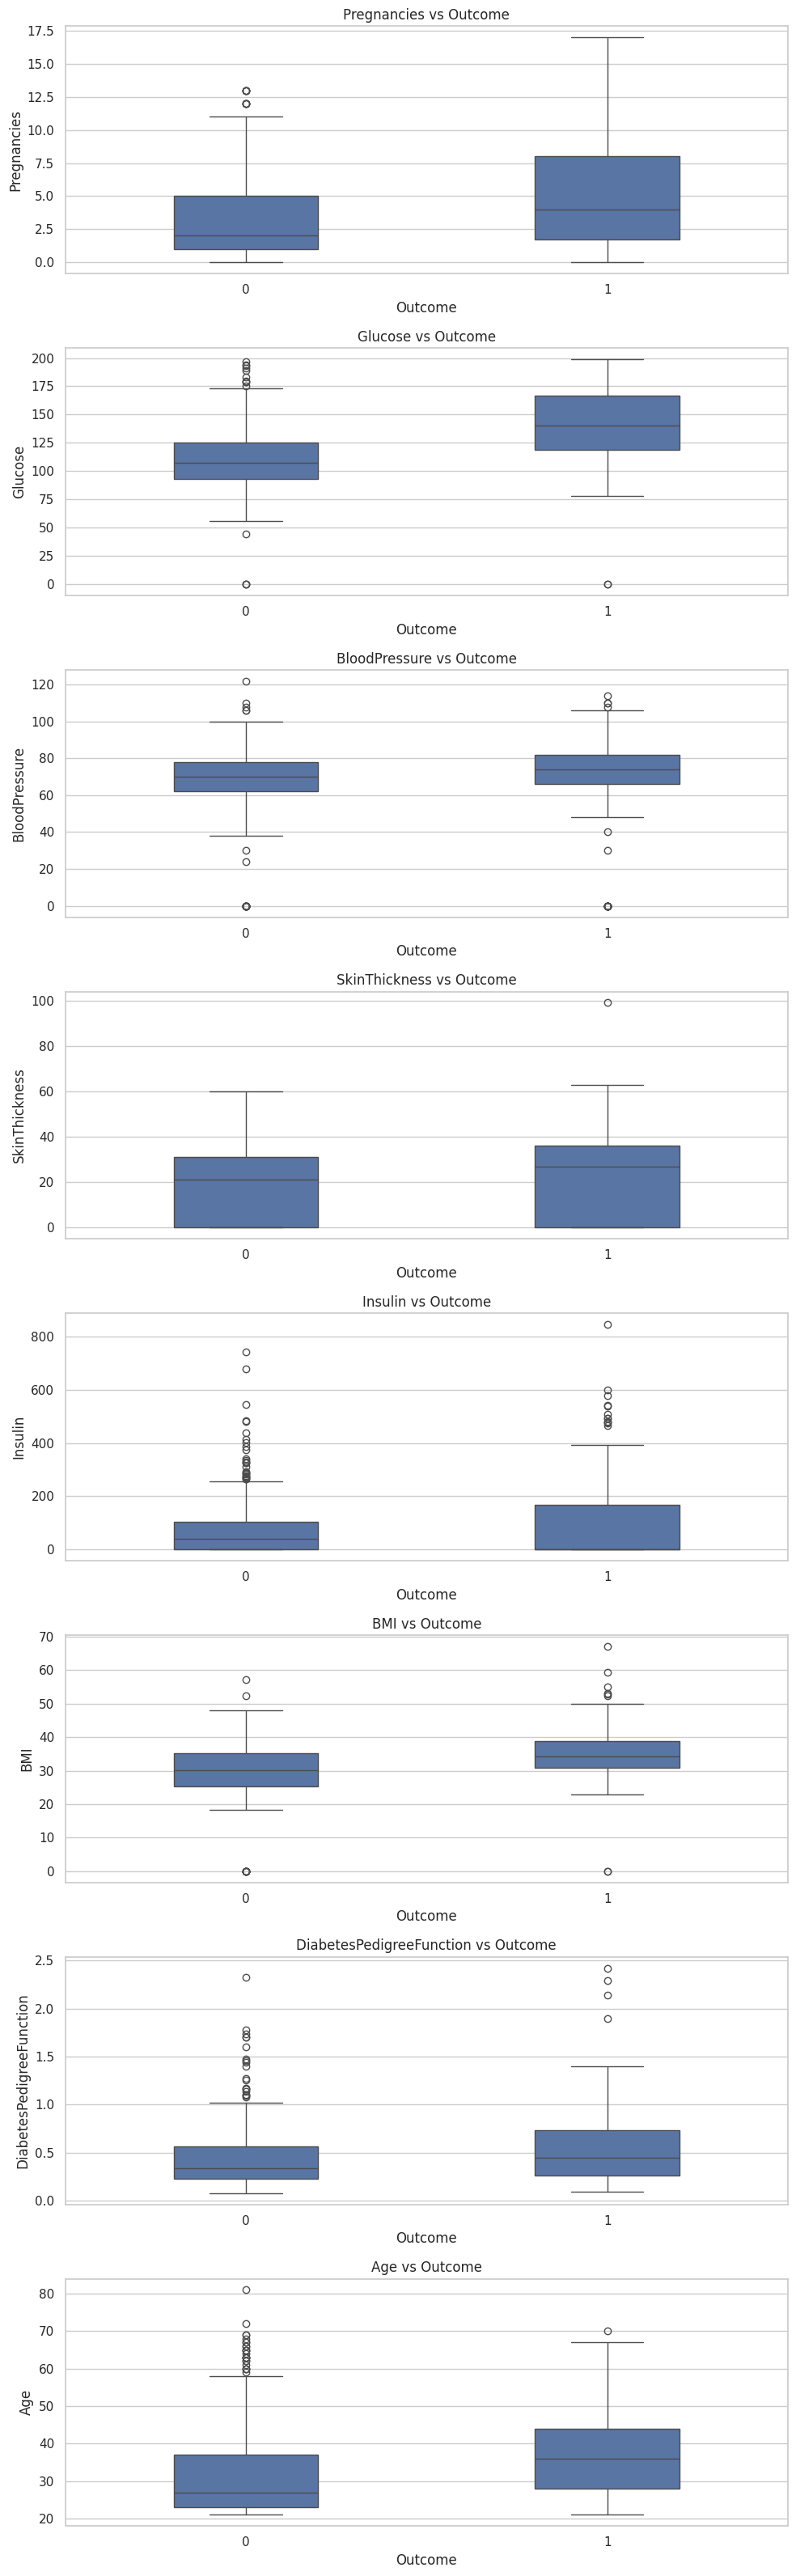

In [12]:
# Variables numéricas (sin el target)
num_vars = df.drop(columns="Outcome").columns

sns.set_style("whitegrid")

fig, axes = plt.subplots(len(num_vars), 1, figsize=(10, 4*len(num_vars)))

for i, col in enumerate(num_vars):
    sns.boxplot(x="Outcome", y=col, data=df, ax=axes[i], width=0.4)
    axes[i].set_title(f"{col} vs Outcome")

plt.tight_layout()
plt.show()

In [13]:
# ============================================
# 2. TABLA (media por grupo)
# ============================================

tabla_medias = df.groupby('Outcome')[num_vars].mean().T

print("\n📊 Media de variables numéricas por grupo (outcome):\n")
display(tabla_medias)


📊 Media de variables numéricas por grupo (outcome):



Outcome,0,1
Pregnancies,3.298000,4.865672
Glucose,109.980000,141.257463
BloodPressure,68.184000,70.824627
SkinThickness,19.664000,22.164179
Insulin,68.792000,100.335821
BMI,30.304200,35.142537
DiabetesPedigreeFunction,0.429734,0.550500
Age,31.190000,37.067164


<div style="background-color:#fff3cd; padding:20px; border-left:8px solid #ffcc00; border-radius:8px; color:#1b1b1b;">

### 💡 **Observación sobre el análisis bivariante (variables numéricas vs `Outcome`)**

A partir del análisis conjunto de los gráficos y la comparación de medias por grupo, se identifican diferencias relevantes entre las variables en función de la variable objetivo `Outcome`.

En particular, `Glucose` muestra una clara separación entre las clases, siendo significativamente mayor en los casos positivos (1), lo que indica una fuerte relación con la presencia de diabetes. Esta diferencia también se refleja en las medias, donde se observa un incremento notable respecto al grupo sin diabetes.

Asimismo, variables como `BMI`, `Age`, `Pregnancies` y `DiabetesPedigreeFunction` presentan valores más elevados en el grupo con `Outcome = 1`, tanto en la visualización como en las medias, lo que sugiere que podrían tener capacidad predictiva, aunque con cierto solapamiento entre clases.

Por otro lado, variables como `BloodPressure` y `SkinThickness` no muestran diferencias tan marcadas entre los grupos, ni en los gráficos ni en los valores medios, lo que podría indicar una menor relevancia individual en la predicción.

En conjunto, el análisis permite identificar a `Glucose` como la variable con mayor capacidad discriminativa, seguida de `BMI`, `Age` y `Pregnancies`, lo que proporciona una base sólida para la fase de modelado.


</div>



<div style="background-color:#d6eaff; border-left:6px solid #4a90e2; padding:15px; border-radius:8px; color:#1b1b1b;">

### **Paso 2.5: Analisis bivariante (categoricas vs target)**

</div>

<div style="background-color:#fff3cd; padding:20px; border-left:8px solid #ffcc00; border-radius:8px; color:#1b1b1b;">

### 💡 **Observación Análisis bivariante (categóricas vs target):**

En este dataset no existen variables categóricas, ya que todas las variables son numéricas.

Por tanto, no es posible realizar un análisis bivariante entre variables categóricas y la variable objetivo `Outcome`.

</div>

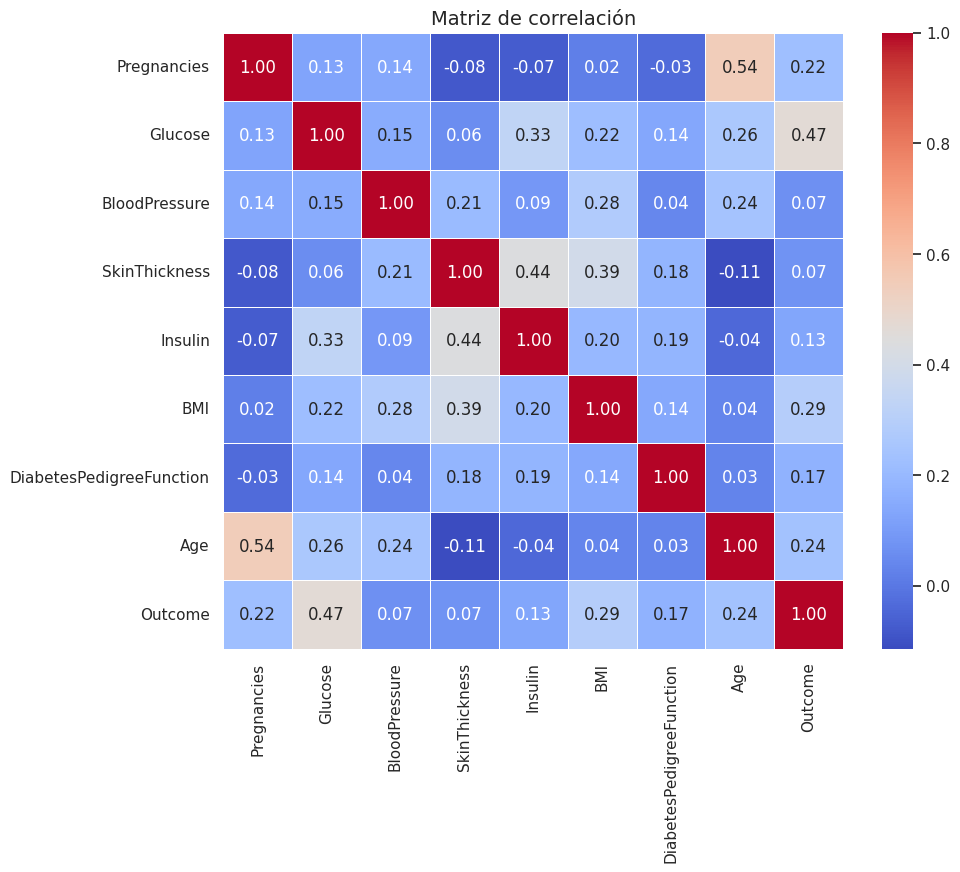

In [14]:
# Matriz de correlación
corr = df.corr()

# Tamaño grande para que se vea bien
plt.figure(figsize=(10, 8))

# Heatmap
sns.heatmap(
    corr,
    annot=True,        # muestra los valores
    fmt=".2f",         # 2 decimales
    cmap="coolwarm",   # colores (rojo/azul)
    linewidths=0.5
)

plt.title("Matriz de correlación", fontsize=14)
plt.show()

<div style="background-color:#fff3cd; padding:20px; border-left:8px solid #ffcc00; border-radius:8px; color:#1b1b1b;">

### **💡 Observación: Análisis de correlación**

A partir de la matriz de correlación se observa que la variable `Glucose` presenta la mayor relación con `Outcome` (0.47), lo que la posiciona como la variable más relevante para la predicción de diabetes.

Otras variables como `BMI` (0.29), `Age` (0.24) y `Pregnancies` (0.22) muestran una correlación moderada, reforzando los patrones observados previamente en el análisis gráfico y en la comparación de medias.

El resto de variables presentan correlaciones débiles, por lo que su impacto en la variable objetivo parece limitado.

<div style="background-color:#d5f5e3; padding:20px; border-left:8px solid #27AE60; border-radius:8px; color:#1b1b1b;">

### 💡 **Conclusión final**

Tras el análisis exploratorio del dataset de diabetes se pueden extraer las siguientes conclusiones:

- Las variables que muestran mayor relación con la variable objetivo `Outcome` son `Glucose`, seguida de `BMI`, `Age` y `Pregnancies`, lo que se ha podido observar tanto en los gráficos como en la matriz de correlación y en el análisis de medias.

- Se han identificado valores iguales a 0 en variables como `Glucose`, `BloodPressure`, `SkinThickness`, `Insulin` y `BMI` que no son plausibles en un contexto médico, por lo que se interpretan como datos faltantes codificados incorrectamente.

- La variable `Insulin` presenta un alto porcentaje de valores cero (~49%), lo que indica posibles problemas de calidad en esta variable.

- La variable `Pregnancies` sí presenta valores coherentes (incluyendo ceros), por lo que no requiere tratamiento.

- El dataset no contiene valores nulos explícitos ni variables categóricas, lo que simplifica el proceso de modelado.

- Se observa un cierto desbalance en la variable objetivo `Outcome`, con mayor proporción de casos negativos que positivos, lo cual deberá tenerse en cuenta en fases posteriores.

En base a estos hallazgos, en la fase de ingeniería de características será necesario tratar los valores faltantes implícitos mediante imputación, así como considerar el impacto de las variables más relevantes en la construcción del modelo.

</div>

<div style="background-color:#d6eaff; border-left:6px solid #4a90e2; padding:15px; border-radius:8px; color:#1b1b1b;">

### **Paso 3: Construye un modelo de árbol de decisión**

</div>

<div style="background-color:#d6eaff; border-left:6px solid #4a90e2; padding:15px; border-radius:8px; color:#1b1b1b;">

### **Paso 3.1: Ingeniería de características**

</div>

<div style="background-color:#fff3cd; padding:20px; border-left:8px solid #ffcc00; border-radius:8px; color:#1b1b1b;">

### 💡 **Acción sobre los valores cero en variables fisicamente imposibles:**

Durante el EDA se identificaron valores iguales a 0 en variables como `Glucose`, `BloodPressure`, `SkinThickness`, `Insulin` y `BMI`, los cuales no son plausibles en un contexto médico.

Estos valores se interpretan como datos faltantes codificados incorrectamente.

Dado que el tamaño del dataset es limitado (768 observaciones), no se considera adecuado eliminar registros. En su lugar, se optará por imputar estos valores para evitar pérdida de información y prevenir que el modelo aprenda patrones erróneos derivados de datos inconsistentes.

La imputación se aplicará únicamente a las variables mencionadas, manteniendo intactas aquellas donde el valor 0 sí es válido, como `Pregnancies`.

</div>

In [15]:
# Creamos una copia del dataset para trabajar sin modificar el original
df_sinceros = df.copy()

In [16]:
# Reemplazamos los valores 0 por NaN en variables donde no son fisiológicamente posibles
cols_with_zeros = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

for col in cols_with_zeros:
    df_sinceros[col] = df_sinceros[col].replace(0, np.nan)

In [17]:
# Imputamos los valores faltantes utilizando la mediana para evitar sesgos por outliers

imputer = SimpleImputer(strategy='median')
df_sinceros[cols_with_zeros] = imputer.fit_transform(df_sinceros[cols_with_zeros])


In [18]:
# Verificamos el número de ceros en todas las variables tras el tratamiento
ceros_sinceros = (df_sinceros == 0).sum()

ceros_sinceros

Pregnancies                 111
Glucose                       0
BloodPressure                 0
SkinThickness                 0
Insulin                       0
BMI                           0
DiabetesPedigreeFunction      0
Age                           0
Outcome                     500
dtype: int64

<div style="background-color:#d6eaff; border-left:6px solid #4a90e2; padding:15px; border-radius:8px; color:#1b1b1b;">

### **Paso 3.2: Separar X y y**

</div>

In [19]:
# Separamos variables predictoras (X) y variable objetivo (y)
X = df_sinceros.drop(columns='Outcome')
y = df_sinceros['Outcome']

<div style="background-color:#d6eaff; border-left:6px solid #4a90e2; padding:15px; border-radius:8px; color:#1b1b1b;">

### **Paso 3.3: Train / Test split**

</div>

In [20]:
# Dividimos los datos en entrenamiento y test manteniendo la proporción de clases
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

X_train.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
353,1,90.0,62.0,12.0,43.0,27.2,0.580,24
711,5,126.0,78.0,27.0,22.0,29.6,0.439,40
373,2,105.0,58.0,40.0,94.0,34.9,0.225,25
46,1,146.0,56.0,29.0,125.0,29.7,0.564,29
682,0,95.0,64.0,39.0,105.0,44.6,0.366,22


<div style="background-color:#fff3cd; padding:20px; border-left:8px solid #ffcc00; border-radius:8px; color:#1b1b1b;">

### 💡 **NOTA:**

Se divide el dataset en conjuntos de entrenamiento y prueba con el objetivo de evaluar la capacidad de generalización del modelo sobre datos no vistos.

Se utiliza un 80% de los datos para entrenamiento y un 20% para prueba, manteniendo la proporción de clases mediante el parámetro stratify, lo que resulta especialmente importante dado el ligero desbalance de la variable objetivo (Outcome).

Además, se fija el parámetro random_state para garantizar la reproducibilidad de los resultados.

</div>

<div style="background-color:#d6eaff; border-left:6px solid #4a90e2; padding:15px; border-radius:8px; color:#1b1b1b;">

### **Paso 3.4: Codificación de variables categóricas**

</div>

<div style="background-color:#fff3cd; padding:20px; border-left:8px solid #ffcc00; border-radius:8px; color:#1b1b1b;">

### 💡 **NOTA:**

En el dataset analizado no se identifican variables categóricas, ya que todas las variables son de tipo numérico.

Por este motivo, no es necesario aplicar ninguna técnicas de codificación.

</div>

<div style="background-color:#d6eaff; border-left:6px solid #4a90e2; padding:15px; border-radius:8px; color:#1b1b1b;">

### **Paso 3.5: Entrenamiento del modelo (Arbol de decisión)**

</div>

In [21]:
# Creamos el modelo
model = DecisionTreeClassifier(random_state=42)

# Entrenamos el modelo
model.fit(X_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current

<div style="background-color:#d6eaff; border-left:6px solid #4a90e2; padding:15px; border-radius:8px; color:#1b1b1b;">

### **Paso 3.6: Metricas del modelo base**

</div>

In [22]:
# Generamos las predicciones del modelo sobre el conjunto de test
y_pred = model.predict(X_test)

In [23]:
# Generamos las predicciones del modelo sobre el conjunto de test
y_pred = model.predict(X_test)

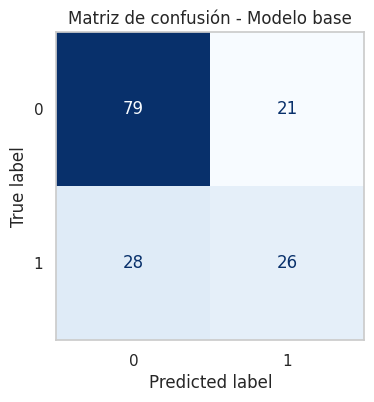

In [24]:
# Mostramos la matriz de confusión en formato gráfico
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)

fig, ax = plt.subplots(figsize=(5, 4))
disp.plot(ax=ax, cmap="Blues", colorbar=False)
plt.title("Matriz de confusión - Modelo base")
plt.grid(False)
plt.show()

In [25]:
# Mostramos el reporte de clasificación del modelo base
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.74      0.79      0.76       100
           1       0.55      0.48      0.51        54

    accuracy                           0.68       154
   macro avg       0.65      0.64      0.64       154
weighted avg       0.67      0.68      0.68       154



<div style="background-color:#d5f5e3; padding:20px; border-left:8px solid #27AE60; border-radius:8px; color:#1b1b1b;">

### 💡 **Observación sobre el modelo base**

El modelo base presenta un rendimiento general moderado. Sin embargo, al analizar la clase positiva (`Outcome = 1`), se observa un recall bajo (~0.48), lo que indica que el modelo no es capaz de detectar correctamente una parte importante de los casos positivos.

En el contexto médico, esto es especialmente crítico, ya que implica que el modelo está dejando sin identificar a un número significativo de pacientes con posible diabetes.

Antes de proceder a la optimización, se evaluará el impacto de los distintos criterios de pureza (`gini` y `entropy`) en el rendimiento del modelo, con especial atención a la mejora del recall de la clase positiva.

</div>

<div style="background-color:#d6eaff; border-left:6px solid #4a90e2; padding:15px; border-radius:8px; color:#1b1b1b;">

### **Modelo con GINI**

</div>

In [26]:
# Entrenamos árbol con criterio Gini
model_gini = DecisionTreeClassifier(criterion='gini', random_state=42)
model_gini.fit(X_train, y_train)

# Predicciones
y_pred_gini = model_gini.predict(X_test)

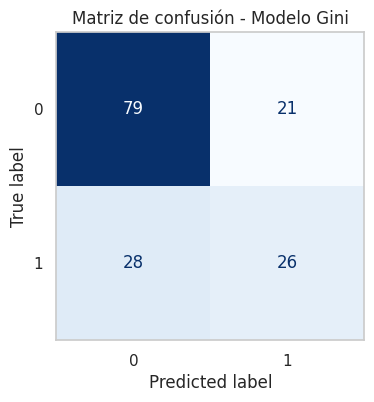

In [27]:
# Mostramos la matriz de confusión del modelo con criterio Gini en formato gráfico
cm_gini = confusion_matrix(y_test, y_pred_gini)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_gini)

fig, ax = plt.subplots(figsize=(5, 4))
disp.plot(ax=ax, cmap="Blues", colorbar=False)
plt.title("Matriz de confusión - Modelo Gini")
plt.grid(False)
plt.show()

In [28]:
# Mostramos el reporte de clasificación del modelo con criterio Gini
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_gini))

              precision    recall  f1-score   support

           0       0.74      0.79      0.76       100
           1       0.55      0.48      0.51        54

    accuracy                           0.68       154
   macro avg       0.65      0.64      0.64       154
weighted avg       0.67      0.68      0.68       154



<div style="background-color:#fff3cd; padding:20px; border-left:8px solid #ffcc00; border-radius:8px; color:#1b1b1b;">

### 💡 **NOTA:**

El modelo base ya utiliza el criterio Gini por defecto, por lo que los resultados obtenidos con este criterio coinciden con los previamente observados. A continuación, se evaluará el criterio Entropy para analizar posibles diferencias en el rendimiento.

</div>

<div style="background-color:#d6eaff; border-left:6px solid #4a90e2; padding:15px; border-radius:8px; color:#1b1b1b;">

### **Modelo con ENTROPY**

</div>

In [29]:
# Entrenamos árbol con criterio Entropy
model_entropy = DecisionTreeClassifier(criterion='entropy', random_state=42)
model_entropy.fit(X_train, y_train)

# Predicciones
y_pred_entropy = model_entropy.predict(X_test)

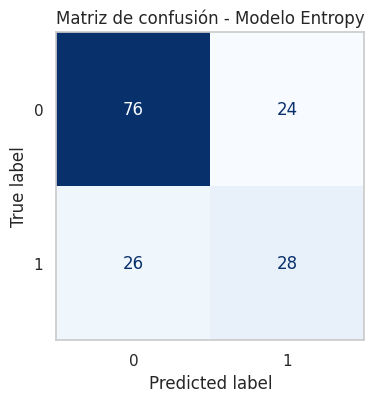

In [30]:
# Matriz de confusión
cm_entropy = confusion_matrix(y_test, y_pred_entropy)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_entropy)

fig, ax = plt.subplots(figsize=(5, 4))
disp.plot(ax=ax, cmap="Blues", colorbar=False)
plt.title("Matriz de confusión - Modelo Entropy")
plt.grid(False)
plt.show()

In [31]:
# Mostramos el reporte de clasificación del modelo con criterio Entropy
print(classification_report(y_test, y_pred_entropy))

              precision    recall  f1-score   support

           0       0.75      0.76      0.75       100
           1       0.54      0.52      0.53        54

    accuracy                           0.68       154
   macro avg       0.64      0.64      0.64       154
weighted avg       0.67      0.68      0.67       154



In [32]:
# Calculamos métricas de ambos modelos para compararlas en una tabla
comparativa = pd.DataFrame({
    'Modelo Gini': [
        accuracy_score(y_test, y_pred_gini),
        precision_score(y_test, y_pred_gini, pos_label=1),
        recall_score(y_test, y_pred_gini, pos_label=1),
        f1_score(y_test, y_pred_gini, pos_label=1),
        recall_score(y_test, y_pred_gini, average='macro'),
        f1_score(y_test, y_pred_gini, average='macro')
    ],
    'Modelo Entropy': [
        accuracy_score(y_test, y_pred_entropy),
        precision_score(y_test, y_pred_entropy, pos_label=1),
        recall_score(y_test, y_pred_entropy, pos_label=1),
        f1_score(y_test, y_pred_entropy, pos_label=1),
        recall_score(y_test, y_pred_entropy, average='macro'),
        f1_score(y_test, y_pred_entropy, average='macro')
    ]
}, index=[
    'Accuracy',
    'Precision (clase 1)',
    'Recall (clase 1)',
    'F1-score (clase 1)',
    'Recall macro',
    'F1-score macro'
])

comparativa.round(3)

,Modelo Gini,Modelo Entropy
Accuracy,0.682,0.675
Precision (clase 1),0.553,0.538
Recall (clase 1),0.481,0.519
F1-score (clase 1),0.515,0.528
Recall macro,0.636,0.639
F1-score macro,0.639,0.640


<div style="background-color:#d6eaff; border-left:6px solid #4a90e2; padding:15px; border-radius:8px; color:#1b1b1b;">

### **Grafico de arboles GINI vs ENTROPY**

</div>

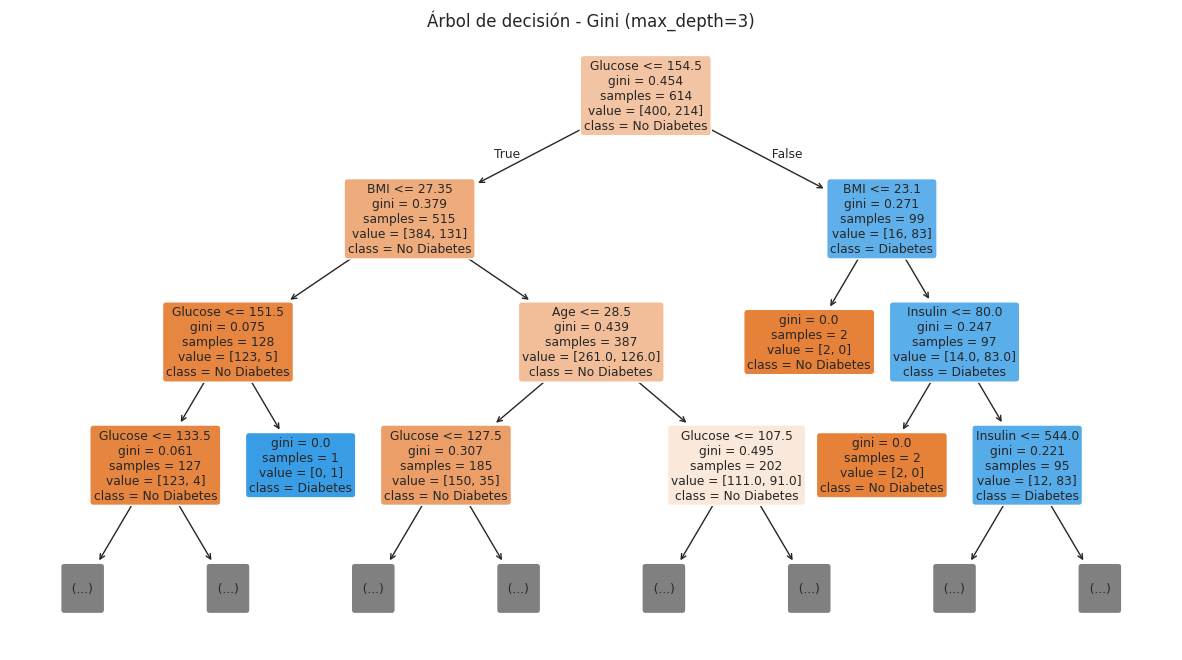

In [33]:
# Visualizamos el árbol con criterio Gini (limitando profundidad para hacerlo legible)

plt.figure(figsize=(15, 8))

plot_tree(
    model_gini,
    feature_names=X.columns,
    class_names=['No Diabetes', 'Diabetes'],
    filled=True,
    rounded=True,
    max_depth=3
)

plt.title("Árbol de decisión - Gini (max_depth=3)")
plt.show()

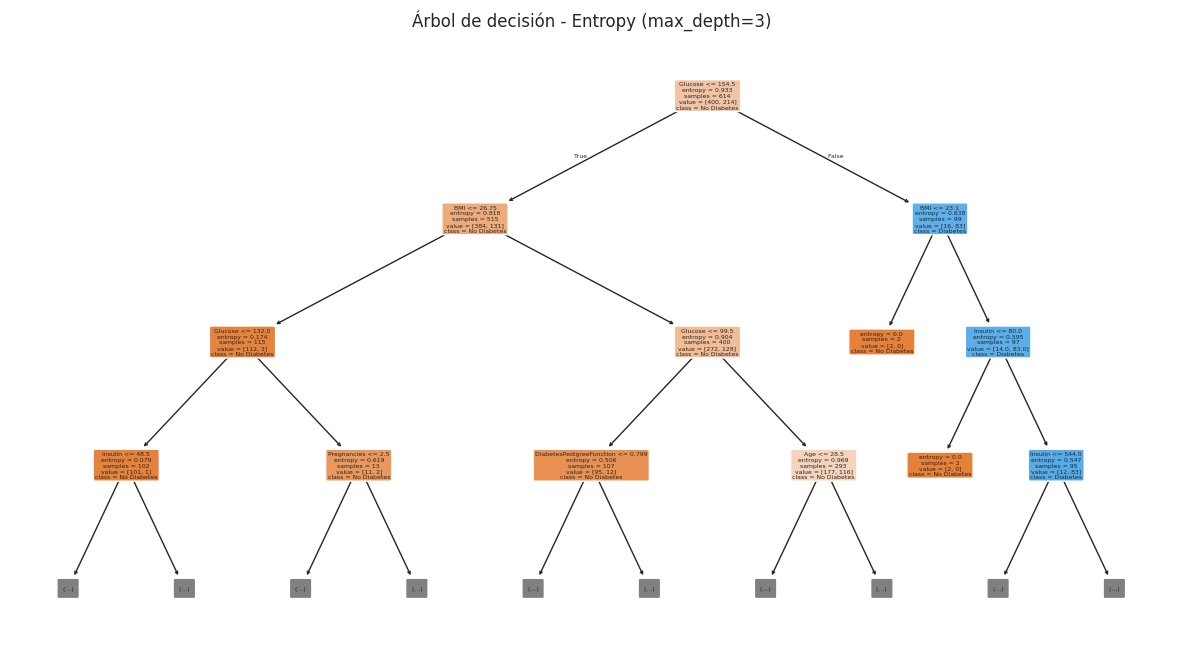

In [34]:
# Visualizamos el árbol con criterio Entropy (limitando profundidad para hacerlo legible)

plt.figure(figsize=(15, 8))

plot_tree(
    model_entropy,
    feature_names=X.columns,
    class_names=['No Diabetes', 'Diabetes'],
    filled=True,
    rounded=True,
    max_depth=3
)

plt.title("Árbol de decisión - Entropy (max_depth=3)")
plt.show()

<div style="background-color:#fff3cd; padding:20px; border-left:8px solid #ffcc00; border-radius:8px; color:#1b1b1b;">

### 💡 **Comparación de criterios de pureza**

Al comparar los modelos entrenados con los criterios `gini` y `entropy`, se observa que ambos presentan un rendimiento general similar.

Sin embargo, la tabla comparativa confirma que ambos modelos presentan un rendimiento general similar. No obstante, el modelo con criterio `entropy` ofrece una mejora ligera en el `recall` y en el `f1-score` de la clase positiva (`Outcome = 1`), que es la de mayor interés en este problema.

Dado que en un contexto médico resulta prioritario detectar correctamente los casos positivos, se considera más adecuado continuar el proceso de optimización utilizando el criterio `entropy`.

Ademas, se observa que ambos árboles presentan estructuras similares, utilizando variables como `Glucose` y `BMI` en los primeros niveles de decisión, lo que refuerza su relevancia en la predicción de la variable objetivo.

</div>

<div style="background-color:#d6eaff; border-left:6px solid #4a90e2; padding:15px; border-radius:8px; color:#1b1b1b;">

### **Paso 4: Optimiza el modelo anterior**

</div>

In [35]:
# Definimos el modelo base con el mejor criterio encontrado (Entropy)
model = DecisionTreeClassifier(criterion='entropy', random_state=42)

In [36]:
# Definimos el grid de hiperparámetros a probar
param_grid = {
    'max_depth': [3, 5, 7, 10, None],
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf': [1, 2, 5, 10]
}

<div style="background-color:#fff3cd; padding:20px; border-left:8px solid #ffcc00; border-radius:8px; color:#1b1b1b;">

### 💡 **Nota: Selección de hiperparámetros**

Se han seleccionado hiperparámetros relacionados con la complejidad del árbol de decisión con el objetivo de controlar el sobreajuste y mejorar la capacidad de generalización del modelo.

- `max_depth`: limita la profundidad del árbol, evitando modelos excesivamente complejos que se ajusten demasiado a los datos de entrenamiento.  
- `min_samples_split`: define el número mínimo de muestras necesarias para dividir un nodo, reduciendo divisiones poco representativas.  
- `min_samples_leaf`: establece el número mínimo de muestras en cada hoja, evitando nodos finales con muy pocos datos.

Los valores elegidos combinan configuraciones más restrictivas y más flexibles, permitiendo al GridSearch explorar distintos niveles de complejidad y encontrar el equilibrio óptimo entre ajuste y generalización.

</div>

In [37]:
# Aplicamos GridSearch optimizando recall de la clase positiva
grid_search = GridSearchCV(
    estimator=model,
    param_grid=param_grid,
    scoring='recall',  
    cv=5,
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",DecisionTreeC...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [3, 5, ...], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [2, 5, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'recall'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- 

<div style="background-color:#fff3cd; padding:20px; border-left:8px solid #ffcc00; border-radius:8px; color:#1b1b1b;">

### 💡 **Nota: Configuración de GridSearch**

Se configuran los parámetros clave del `GridSearchCV` en función del objetivo del problema:

- `scoring='recall'`: se optimiza el recall de la clase positiva (`Outcome = 1`), ya que en un contexto médico es prioritario detectar la mayor cantidad posible de casos de diabetes y minimizar los falsos negativos.  
- `cv=5`: se utiliza validación cruzada con 5 particiones para obtener una estimación más robusta del rendimiento del modelo, reduciendo la dependencia de una única división de los datos.  
- `n_jobs=-1`: permite utilizar todos los núcleos disponibles del procesador para acelerar el proceso de búsqueda de hiperparámetros.

</div>

In [38]:
# Mejores hiperparámetros encontrados
print("Mejores parámetros:")
print(grid_search.best_params_)

# Mejor score
print("\nMejor recall (validación cruzada):")
print(grid_search.best_score_)

Mejores parámetros:
{'max_depth': 7, 'min_samples_leaf': 10, 'min_samples_split': 2}

Mejor recall (validación cruzada):
0.6637873754152824


In [39]:
# Obtenemos el mejor modelo
best_model = grid_search.best_estimator_

# Predicciones
y_pred_opt = best_model.predict(X_test)

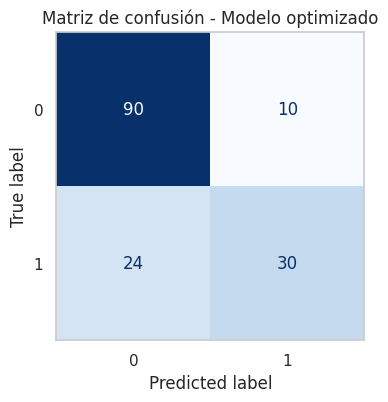

In [40]:
cm_opt = confusion_matrix(y_test, y_pred_opt)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_opt)

fig, ax = plt.subplots(figsize=(5, 4))
disp.plot(ax=ax, cmap="Blues", colorbar=False)
plt.title("Matriz de confusión - Modelo optimizado")
plt.grid(False)
plt.show()

In [41]:
print(classification_report(y_test, y_pred_opt))

              precision    recall  f1-score   support

           0       0.79      0.90      0.84       100
           1       0.75      0.56      0.64        54

    accuracy                           0.78       154
   macro avg       0.77      0.73      0.74       154
weighted avg       0.78      0.78      0.77       154



<div style="background-color:#d5f5e3; padding:20px; border-left:8px solid #27AE60; border-radius:8px; color:#1b1b1b;">

### 💡 **Observación sobre el modelo optimizado**

Tras la optimización de hiperparámetros mediante GridSearch, se ha logrado mejorar la capacidad del modelo para detectar la clase positiva (`Outcome = 1`), incrementando el recall respecto al modelo base.

Este resultado es especialmente relevante en el contexto médico, donde es prioritario reducir los falsos negativos y detectar la mayor cantidad posible de pacientes con diabetes.

El modelo optimizado presenta una configuración más restrictiva (mayor control sobre la profundidad y tamaño de las hojas), lo que contribuye a una mejor generalización y a una toma de decisiones más robusta.

No obstante, esta mejora en el recall puede implicar un ligero compromiso en otras métricas como la precisión, lo cual se considera aceptable dado el objetivo del problema.

</div>

<div style="background-color:#d6eaff; border-left:6px solid #4a90e2; padding:15px; border-radius:8px; color:#1b1b1b;">

### **Paso 5: Guardar el modelo**

</div>

In [42]:
# Guardamos el modelo optimizado
joblib.dump(best_model, '../models/decision_tree_diabetes.sav')

['../models/decision_tree_diabetes.sav']